# 1. Initial check
## GPU Check

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())
else:
    print("Using CPU")

CUDA available: True
GPU name: NVIDIA H100 80GB HBM3
GPU count: 1


# 2. Dataset

In [2]:
# import os

# # Check if the path exists and list files
# root = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/"
# print("Exists:", os.path.exists(root))
# print("Files:", os.listdir(root))

# # Check the contents of the base directory
# base = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Test"
# print(os.listdir(base)[:10])

# # Check the contents of one class directory
# sample_class = os.listdir(base)[0]
# sample_path = os.path.join(base, sample_class)
# print("Class:", sample_class)
# print("Files:", os.listdir(sample_path)[:5])

### Dataset interpretation
- Real_Train
    - Darkening-1
        - '01_14_04_01_0033.bmp'
        - '01_01_04_01_0276.bmp'
        - ...
    - Rain-3
    - Haze-5 （challenge type + level）
    - ...
- Real_Test
- Unreal_Train
- Unreal_Test

Explaination:
- The name format of the provided images are as follows: "sequenceType_signType_challengeType_challengeLevel_Index.bmp"
    - sequenceType: 
        - 01 - Real data 
        - 02 - Unreal data
    - signType: 
        - 01 - speed_limit 
        - 02 - goods_vehicles 
        - 03 - no_overtaking 
        - 04 - no_stopping 
        - 05 - no_parking 
        - 06 - stop 
        - 07 - bicycle 
        - 08 - hump 
        - 09 - no_left 
        - 10 - no_right 
        - 11 - priority_to 
        - 12 - no_entry 
        - 13 - yield 
        - 14 - parking
    - challengeType: 
        - 00 - No challenge 
        - 01 - Decolorization 
        - 02 - Lens blur 
        - 03 - Codec error 
        - 04 - Darkening 
        - 05 - Dirty lens 
        - 06 - Exposure 
        - 07 - Gaussian blur 
        - 08 - Noise 
        - 09 - Rain 
        - 10 - Shadow 
        - 11 - Snow 
        - 12 - Haze
    - challengeLevel: A number in between [01-05] where 01 is the least severe and 05 is the most severe challenge.

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TrafficSignDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self._load_data()

        if len(self.samples) == 0:
            raise ValueError(f"No .bmp files found in {self.root_dir}")

    def _parse_filename(self, filename):
        """
        filename format:
        sequenceType_signType_challengeType_challengeLevel_Index.bmp
        """
        name = filename.replace(".bmp", "")
        parts = name.split("_")

        sequenceType = int(parts[0])   # 01 real / 02 unreal
        signType = int(parts[1])       # signType label
        challengeType = int(parts[2])  # corruption type
        challengeLevel = int(parts[3]) # severity

        return sequenceType, signType, challengeType, challengeLevel

    def _load_data(self):
        for root, _, files in os.walk(self.root_dir):
            for f in files:
                if f.lower().endswith(".bmp"):
                    full_path = os.path.join(root, f)
                    sequenceType, signType, challengeType, challengeLevel = self._parse_filename(f)

                    self.samples.append({
                        "path": full_path,
                        "sequenceType": sequenceType,         # 1 = real, 2 = unreal
                        "signType": signType - 1,          # make signType label 0-based
                        "challengeType": challengeType,
                        "challengeLevel": challengeLevel,
                        "filename": f
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return {
            "image": img,
            "sequenceType": sample["sequenceType"],
            "signType": sample["signType"],
            "challengeType": sample["challengeType"],
            "challengeLevel": sample["challengeLevel"],
            "filename": sample["filename"],
            "path": sample["path"]
        }

In [4]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

root = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/"

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

real_train_dataset = TrafficSignDataset(os.path.join(root, "Real_Train"), transform=transform)
real_test_dataset = TrafficSignDataset(os.path.join(root, "Real_Test"), transform=transform)
unreal_train_dataset = TrafficSignDataset(os.path.join(root, "Unreal_Train"), transform=transform)
unreal_test_dataset = TrafficSignDataset(os.path.join(root, "Unreal_Test"), transform=transform)

print("real_train_dataset:", len(real_train_dataset))
print("real_test_dataset:", len(real_test_dataset))
print("unreal_train_dataset:", len(unreal_train_dataset))
print("unreal_test_dataset:", len(unreal_test_dataset))

real_train_dataset: 444806
real_test_dataset: 203374
unreal_train_dataset: 1098160
unreal_test_dataset: 459760


In [5]:
Real_Train = DataLoader(real_train_dataset, batch_size=64, shuffle=True)
Real_Test = DataLoader(real_test_dataset, batch_size=64, shuffle=False)
Unreal_Train = DataLoader(unreal_train_dataset, batch_size=64, shuffle=True)
Unreal_Test = DataLoader(unreal_test_dataset, batch_size=64, shuffle=False)

In [6]:
# test dataset loading
print("First 2 samples from each dataset:")

for i in range(2):
    print("\n[Real_Train]", real_train_dataset.samples[i])
    print("[Real_Test]", real_test_dataset.samples[i])
    print("[Unreal_Train]", unreal_train_dataset.samples[i])
    print("[Unreal_Test]", unreal_test_dataset.samples[i])

First 2 samples from each dataset:

[Real_Train] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Train/Darkening-1/01_14_04_01_0033.bmp', 'sequenceType': 1, 'signType': 13, 'challengeType': 4, 'challengeLevel': 1, 'filename': '01_14_04_01_0033.bmp'}
[Real_Test] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Real_Test/Darkening-1/01_14_04_01_0033.bmp', 'sequenceType': 1, 'signType': 13, 'challengeType': 4, 'challengeLevel': 1, 'filename': '01_14_04_01_0033.bmp'}
[Unreal_Train] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Unreal_Train/Darkening-1/02_01_04_01_0926.bmp', 'sequenceType': 2, 'signType': 0, 'challengeType': 4, 'challengeLevel': 1, 'filename': '02_01_04_01_0926.bmp'}
[Unreal_Test] {'path': '/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR/Unreal_Test/Darkening-1/02_14_04_01_0572.bmp', 'sequenceType': 2, 'signType': 13, 'challengeType': 4, 'challenge

# 3. Metrics

metrics needed:

- logits: [N, K]
- probs: [N, K]
- labels: [N]
- accept_mask: [N]，布尔值，表示是否接受预测
- ood_scores: [N]，越大越像 OOD 或越不确定
- id_scores: [N]，ID 数据上的对应分数

In [7]:
import math
import numpy as np
import torch
import torch.nn.functional as F


# =========================================================
# Basic helpers
# =========================================================
def to_probs(logits: torch.Tensor) -> torch.Tensor:
    """
    Convert logits [N, K] to probabilities [N, K].
    """
    return torch.softmax(logits, dim=1)


def safe_log(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return torch.log(torch.clamp(x, min=eps))

In [8]:
# =========================================================
# 1. Clean Accuracy
# =========================================================
def clean_accuracy_from_probs(probs: torch.Tensor, labels: torch.Tensor) -> float:
    """
    probs: [N, K]
    labels: [N]
    """
    preds = probs.argmax(dim=1)
    acc = (preds == labels).float().mean().item()
    return float(acc)


def clean_accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
    return clean_accuracy_from_probs(to_probs(logits), labels)


## 3.1 Uncertainty / Calibration
### 3.1.1 NLL

In [9]:
# =========================================================
# 2. NLL (Negative Log Likelihood)
# =========================================================
def negative_log_likelihood(probs: torch.Tensor, labels: torch.Tensor) -> float:
    """
    Multi-class NLL.
    Lower is better.
    """
    true_class_probs = probs[torch.arange(len(labels)), labels]
    nll = -safe_log(true_class_probs).mean().item()
    return float(nll)

### 3.1.2 Brier

In [10]:
# =========================================================
# 3. Brier Score
# =========================================================
def brier_score(probs: torch.Tensor, labels: torch.Tensor, num_classes: int = None) -> float:
    """
    Multi-class Brier score.
    Lower is better.
    """
    if num_classes is None:
        num_classes = probs.shape[1]

    one_hot = F.one_hot(labels, num_classes=num_classes).float()
    bs = ((probs - one_hot) ** 2).sum(dim=1).mean().item()
    return float(bs)

### 3.1.3 Calibration

In [11]:
# =========================================================
# 4. Calibration
# =========================================================
def expected_calibration_error(
    probs: torch.Tensor,
    labels: torch.Tensor,
    n_bins: int = 15
) -> float:
    """
    Standard ECE.
    Lower is better.
    """
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels).float()

    bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    ece = torch.zeros(1, device=probs.device)

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        prop_in_bin = in_bin.float().mean()
        if prop_in_bin.item() > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += torch.abs(conf_in_bin - acc_in_bin) * prop_in_bin

    return float(ece.item())


def calibration_table(
    probs: torch.Tensor,
    labels: torch.Tensor,
    n_bins: int = 15
):
    """
    Returns a list of per-bin stats for reliability diagrams.
    """
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels).float()

    bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=probs.device)
    rows = []

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        if i == 0:
            in_bin = (confidences >= lower) & (confidences <= upper)
        else:
            in_bin = (confidences > lower) & (confidences <= upper)

        count = int(in_bin.sum().item())
        if count > 0:
            rows.append({
                "bin_lower": float(lower.item()),
                "bin_upper": float(upper.item()),
                "count": count,
                "avg_confidence": float(confidences[in_bin].mean().item()),
                "avg_accuracy": float(accuracies[in_bin].mean().item()),
            })
        else:
            rows.append({
                "bin_lower": float(lower.item()),
                "bin_upper": float(upper.item()),
                "count": 0,
                "avg_confidence": float("nan"),
                "avg_accuracy": float("nan"),
            })

    return rows

### 3.1.4 OOD entropy/confidence

In [12]:
# =========================================================
# 5. OOD Detection
# =========================================================
def max_softmax_probability(probs: torch.Tensor) -> torch.Tensor:
    """
    Higher MSP => more likely ID
    """
    return probs.max(dim=1).values


def predictive_entropy(probs: torch.Tensor) -> torch.Tensor:
    """
    Higher entropy => more uncertain / more likely OOD
    """
    return -(probs * safe_log(probs)).sum(dim=1)


def _binary_roc_auc_from_scores(id_scores: np.ndarray, ood_scores: np.ndarray, higher_means_ood: bool = True) -> float:
    """
    Simple AUROC implementation without sklearn.

    id_scores: scores on ID samples
    ood_scores: scores on OOD samples
    higher_means_ood:
        True  -> larger score = more OOD
        False -> larger score = more ID
    """
    y_true = np.concatenate([np.zeros(len(id_scores)), np.ones(len(ood_scores))])  # 0=ID, 1=OOD
    scores = np.concatenate([id_scores, ood_scores])

    if not higher_means_ood:
        scores = -scores

    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(len(scores)) + 1

    n_ood = len(ood_scores)
    n_id = len(id_scores)

    sum_ranks_ood = ranks[y_true == 1].sum()
    auc = (sum_ranks_ood - n_ood * (n_ood + 1) / 2) / (n_ood * n_id)
    return float(auc)


def ood_auroc_from_entropy(id_probs: torch.Tensor, ood_probs: torch.Tensor) -> float:
    """
    Higher entropy => more OOD
    """
    id_scores = predictive_entropy(id_probs).detach().cpu().numpy()
    ood_scores = predictive_entropy(ood_probs).detach().cpu().numpy()
    return _binary_roc_auc_from_scores(id_scores, ood_scores, higher_means_ood=True)


def ood_auroc_from_msp(id_probs: torch.Tensor, ood_probs: torch.Tensor) -> float:
    """
    Lower MSP => more OOD
    """
    id_scores = max_softmax_probability(id_probs).detach().cpu().numpy()
    ood_scores = max_softmax_probability(ood_probs).detach().cpu().numpy()
    return _binary_roc_auc_from_scores(id_scores, ood_scores, higher_means_ood=False)


def ood_detection_summary(id_probs: torch.Tensor, ood_probs: torch.Tensor):
    return {
        "OOD_AUROC_entropy": ood_auroc_from_entropy(id_probs, ood_probs),
        "OOD_AUROC_MSP": ood_auroc_from_msp(id_probs, ood_probs),
        "ID_mean_entropy": float(predictive_entropy(id_probs).mean().item()),
        "OOD_mean_entropy": float(predictive_entropy(ood_probs).mean().item()),
        "ID_mean_MSP": float(max_softmax_probability(id_probs).mean().item()),
        "OOD_mean_MSP": float(max_softmax_probability(ood_probs).mean().item()),
    }

## 3.2 Selective Classification
### 3.2.1 Risk and Coverage

In [13]:
# =========================================================
# 6. Risk and Coverage
# =========================================================
def coverage(accept_mask: torch.Tensor) -> float:
    """
    Coverage = fraction of accepted samples
    """
    return float(accept_mask.float().mean().item())


def selective_risk(probs: torch.Tensor, labels: torch.Tensor, accept_mask: torch.Tensor) -> float:
    """
    Risk over accepted samples only.
    Lower is better.
    """
    accept_mask = accept_mask.bool()
    if accept_mask.sum().item() == 0:
        return float("nan")

    preds = probs.argmax(dim=1)
    errors = (preds != labels).float()
    risk = errors[accept_mask].mean().item()
    return float(risk)


def risk_coverage_summary(probs: torch.Tensor, labels: torch.Tensor, accept_mask: torch.Tensor):
    return {
        "coverage": coverage(accept_mask),
        "risk": selective_risk(probs, labels, accept_mask),
    }

## 3.3 Corruption Robustness
### 3.3.1 Mean Corruption Error and Relative mCE

In [14]:
# =========================================================
# 7. Corruption Robustness: mCE and Relative mCE
# =========================================================
def corruption_error(error_rates_across_severities, alexnet_error_across_severities):
    """
    CE for one corruption type.

    error_rates_across_severities: list of model error rates at severity 1..5
    alexnet_error_across_severities: list of AlexNet error rates at severity 1..5
    """
    num = np.sum(error_rates_across_severities)
    den = np.sum(alexnet_error_across_severities)
    return float(num / den)


def relative_corruption_error(
    error_rates_across_severities,
    clean_error,
    alexnet_error_across_severities,
    alexnet_clean_error
):
    """
    Relative CE for one corruption type.
    """
    num = np.sum(error_rates_across_severities) - clean_error
    den = np.sum(alexnet_error_across_severities) - alexnet_clean_error
    return float(num / den)


def mean_corruption_error(
    corruption_dict,
    alexnet_corruption_dict
):
    """
    corruption_dict:
        {
            'gaussian_noise': [e1, e2, e3, e4, e5],
            'blur': [...],
            ...
        }

    alexnet_corruption_dict:
        same structure with AlexNet errors
    """
    ces = []
    for corruption_name in corruption_dict:
        ce = corruption_error(
            corruption_dict[corruption_name],
            alexnet_corruption_dict[corruption_name]
        )
        ces.append(ce)
    return float(np.mean(ces))


def relative_mce(
    corruption_dict,
    clean_error,
    alexnet_corruption_dict,
    alexnet_clean_error
):
    rces = []
    for corruption_name in corruption_dict:
        rce = relative_corruption_error(
            corruption_dict[corruption_name],
            clean_error,
            alexnet_corruption_dict[corruption_name],
            alexnet_clean_error
        )
        rces.append(rce)
    return float(np.mean(rces))

## 3.4 Metrics summrization

In [15]:
# =========================================================
# 8. Unified metrics summary
# =========================================================
def evaluate_id_metrics(
    probs: torch.Tensor,
    labels: torch.Tensor,
    accept_mask: torch.Tensor = None,
    n_bins: int = 15
):
    results = {
        "clean_accuracy": clean_accuracy_from_probs(probs, labels),
        "NLL": negative_log_likelihood(probs, labels),
        "Brier": brier_score(probs, labels),
        "ECE": expected_calibration_error(probs, labels, n_bins=n_bins),
    }

    if accept_mask is not None:
        results["coverage"] = coverage(accept_mask)
        results["risk"] = selective_risk(probs, labels, accept_mask)

    return results


def evaluate_ood_metrics(
    id_probs: torch.Tensor,
    ood_probs: torch.Tensor
):
    return ood_detection_summary(id_probs, ood_probs)


def evaluate_corruption_metrics(
    corruption_dict,
    clean_error,
    alexnet_corruption_dict,
    alexnet_clean_error
):
    return {
        "mCE": mean_corruption_error(corruption_dict, alexnet_corruption_dict),
        "Relative_mCE": relative_mce(
            corruption_dict,
            clean_error,
            alexnet_corruption_dict,
            alexnet_clean_error
        )
    }


def evaluate_all_metrics(
    id_probs: torch.Tensor,
    id_labels: torch.Tensor,
    ood_probs: torch.Tensor = None,
    accept_mask: torch.Tensor = None,
    corruption_dict = None,
    clean_error: float = None,
    alexnet_corruption_dict = None,
    alexnet_clean_error: float = None,
    n_bins: int = 15
):
    results = {}
    results.update(
        evaluate_id_metrics(
            probs=id_probs,
            labels=id_labels,
            accept_mask=accept_mask,
            n_bins=n_bins
        )
    )

    if ood_probs is not None:
        results.update(
            evaluate_ood_metrics(
                id_probs=id_probs,
                ood_probs=ood_probs
            )
        )

    if (
        corruption_dict is not None
        and clean_error is not None
        and alexnet_corruption_dict is not None
        and alexnet_clean_error is not None
    ):
        results.update(
            evaluate_corruption_metrics(
                corruption_dict=corruption_dict,
                clean_error=clean_error,
                alexnet_corruption_dict=alexnet_corruption_dict,
                alexnet_clean_error=alexnet_clean_error
            )
        )

    return results

## 3.5 Reusable evaluation helpers

In [16]:
# =========================================================
# 9. Collect model outputs from a dataloader
# =========================================================
@torch.no_grad()
def collect_probs_and_labels(model, loader, device="cuda"):
    model.eval()
    all_probs = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        probs = to_probs(logits)

        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_probs, dim=0), torch.cat(all_labels, dim=0)


@torch.no_grad()
def collect_logits_probs_labels(model, loader, device="cuda"):
    model.eval()
    all_logits = []
    all_probs = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        probs = to_probs(logits)

        all_logits.append(logits.cpu())
        all_probs.append(probs.cpu())
        all_labels.append(labels.cpu())

    return (
        torch.cat(all_logits, dim=0),
        torch.cat(all_probs, dim=0),
        torch.cat(all_labels, dim=0),
    )

In [17]:
# =========================================================
# 10. Acceptance masks for operating envelope / uncertainty gating
# =========================================================
def accept_by_msp(probs: torch.Tensor, threshold: float) -> torch.Tensor:
    return max_softmax_probability(probs) >= threshold


def accept_by_entropy(probs: torch.Tensor, threshold: float) -> torch.Tensor:
    return predictive_entropy(probs) <= threshold


def combined_accept_mask(
    probs: torch.Tensor,
    msp_threshold: float = None,
    entropy_threshold: float = None
) -> torch.Tensor:
    mask = torch.ones(len(probs), dtype=torch.bool)

    if msp_threshold is not None:
        mask = mask & accept_by_msp(probs, msp_threshold)

    if entropy_threshold is not None:
        mask = mask & accept_by_entropy(probs, entropy_threshold)

    return mask

In [18]:
# =========================================================
# 11. Risk-coverage curve helper
# =========================================================
def risk_coverage_curve_from_msp(
    probs: torch.Tensor,
    labels: torch.Tensor,
    num_thresholds: int = 50
):
    scores = max_softmax_probability(probs)
    thresholds = torch.linspace(float(scores.min()), float(scores.max()), num_thresholds)

    curve = []
    for t in thresholds:
        mask = scores >= t
        curve.append({
            "threshold": float(t.item()),
            "coverage": coverage(mask),
            "risk": selective_risk(probs, labels, mask),
        })
    return curve


def risk_coverage_curve_from_entropy(
    probs: torch.Tensor,
    labels: torch.Tensor,
    num_thresholds: int = 50
):
    scores = predictive_entropy(probs)
    thresholds = torch.linspace(float(scores.min()), float(scores.max()), num_thresholds)

    curve = []
    for t in thresholds:
        mask = scores <= t
        curve.append({
            "threshold": float(t.item()),
            "coverage": coverage(mask),
            "risk": selective_risk(probs, labels, mask),
        })
    return curve

In [19]:
# =========================================================
# 12. Corruption evaluation template
# =========================================================
def build_corruption_error_dict(results_by_corruption_and_severity):
    """
    Input:
        {
            "gaussian_noise": {1: err1, 2: err2, 3: err3, 4: err4, 5: err5},
            "blur": {1: err1, 2: err2, 3: err3, 4: err4, 5: err5},
        }

    Output:
        {
            "gaussian_noise": [err1, err2, err3, err4, err5],
            "blur": [err1, err2, err3, err4, err5],
        }
    """
    corruption_dict = {}
    for corruption_name, sev_dict in results_by_corruption_and_severity.items():
        corruption_dict[corruption_name] = [sev_dict[s] for s in sorted(sev_dict.keys())]
    return corruption_dict

# 4. Baseline

### 4.2 Linear Classifier

In [20]:
import torch
import torch.nn as nn

class LinearClassifier(nn.Module):
    def __init__(self, num_classes=14, input_size=64):
        """
        input_size: 你的图像尺寸 (64x64)
        """
        super().__init__()
        self.fc = nn.Linear(3 * input_size * input_size, num_classes)

    def forward(self, x):
        # x: [B, 3, 64, 64]
        x = x.view(x.size(0), -1)  # flatten
        logits = self.fc(x)
        return logits

In [21]:
import torch
import torch.nn.functional as F

def train_linear_model(model, train_loader, val_loader, epochs=10, lr=1e-3, device="cpu"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                labels = batch["label"].to(device)

                logits = model(images)
                preds = logits.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        print(f"Epoch {epoch+1}, Loss: {total_loss:.3f}, Val Acc: {correct/total:.4f}")

    return model

In [22]:
def collect_model_outputs(model, loader, device="cpu"):
    model.eval()

    all_logits = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            all_logits.append(logits.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_logits, all_probs, all_labels

### ResNet

In [23]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, Subset

class ResNetBaseline(nn.Module):
    """
    ResNet-18 adapted for 64×64 CURE-TSR images (14 traffic-sign classes).

    Modifications vs. standard ResNet-18:
      - conv1   : 7×7 stride-2  →  3×3 stride-1  (avoid over-downsampling)
      - maxpool : replaced with Identity           (preserve spatial resolution)
    """
    def __init__(self, num_classes: int = 14):
        super().__init__()
        backbone         = models.resnet18(weights=None)
        backbone.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        backbone.fc      = nn.Linear(backbone.fc.in_features, num_classes)
        self.net = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

n_params = sum(p.numel() for p in ResNetBaseline().parameters())
print(f"ResNetBaseline defined.  Params: {n_params:,}")

ResNetBaseline defined.  Params: 11,176,014


## 5. Training & Results

### 5.1 Baseline Training

In [24]:
# ─── Data split: train on low challenge, evaluate on high challenge ───────────

def filter_by_challenge_level(dataset, levels):
    """
    Return a torch.utils.data.Subset containing only samples whose
    challengeLevel is in `levels`.  `dataset` must be a TrafficSignDataset
    (exposes the .samples list).
    """
    indices = [
        i for i, s in enumerate(dataset.samples)
        if s["challengeLevel"] in levels
    ]
    return Subset(dataset, indices)

LOW_LEVELS  = [1, 2]   # mild corruption  → baseline's training domain
HIGH_LEVELS = [4, 5]   # severe corruption → OOD / distribution-shifted test

baseline_train_set = filter_by_challenge_level(real_train_dataset, LOW_LEVELS)
baseline_val_set   = filter_by_challenge_level(real_test_dataset,  LOW_LEVELS)
baseline_ood_set   = filter_by_challenge_level(real_test_dataset,  HIGH_LEVELS)

print(f"Train  (level 1-2): {len(baseline_train_set):>9,}")
print(f"Val    (level 1-2): {len(baseline_val_set):>9,}")
print(f"OOD    (level 4-5): {len(baseline_ood_set):>9,}")

_bs = 128
_lkw = dict(num_workers=4, pin_memory=True, persistent_workers=True)

baseline_train_loader = DataLoader(baseline_train_set, batch_size=_bs, shuffle=True,  **_lkw)
baseline_val_loader   = DataLoader(baseline_val_set,   batch_size=_bs, shuffle=False, **_lkw)
baseline_ood_loader   = DataLoader(baseline_ood_set,   batch_size=_bs, shuffle=False, **_lkw)

Train  (level 1-2):   175,002
Val    (level 1-2):    80,016
OOD    (level 4-5):    80,016


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [25]:
# ─── Training Functions────────────────────────────────────────────────────────────────
import time
import sys

def _train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    model.train()
    total_loss, n = 0.0, 0
    n_batches = len(loader)
    for batch in loader:
        imgs   = batch["image"].to(device)
        labels = batch["signType"].to(device)
        loss   = criterion(model(imgs), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n += 1

        if n % 50 == 0 or n == n_batches:
            print(f"  Epoch {epoch}/{total_epochs}  batch {n}/{n_batches}"
                  f"  avg_loss={total_loss/n:.4f}", flush=True)
    return total_loss / n


@torch.no_grad()
def _eval_acc(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for batch in loader:
        preds  = model(batch["image"].to(device)).argmax(dim=1)
        labels = batch["signType"].to(device)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total


def train_baseline_resnet(model, train_loader, val_loader,
                          epochs=10, lr=1e-3, weight_decay=1e-4,
                          device="cuda", save_path="baseline_resnet.pth"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    history   = {"loss": [], "val_acc": []}

    for ep in range(1, epochs + 1):
        t0      = time.time()
        loss    = _train_one_epoch(model, train_loader, optimizer, criterion, device, ep, epochs)
        val_acc = _eval_acc(model, val_loader, device)
        scheduler.step()
        elapsed = time.time() - t0

        history["loss"].append(loss)
        history["val_acc"].append(val_acc)
        print(f"[Epoch {ep:3d}/{epochs}]  loss={loss:.4f}  val_acc={val_acc:.4f}  ({elapsed:.0f}s)",
              flush=True)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"\nBest val_acc = {best_acc:.4f}  →  saved: {save_path}")
    return history


@torch.no_grad()
def collect_outputs(model, loader, device="cuda"):
    """Return (probs [N, K], labels [N]) from a DataLoader."""
    model.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        logits = model(batch["image"].to(device))
        all_probs.append(torch.softmax(logits, dim=1).cpu())
        all_labels.append(batch["signType"])
    return torch.cat(all_probs), torch.cat(all_labels)


In [26]:
# ── Training ──────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}\n")

baseline_model   = ResNetBaseline(num_classes=14)
baseline_history = train_baseline_resnet(
    baseline_model,
    baseline_train_loader,
    baseline_val_loader,
    epochs=5,
    lr=1e-3,
    device=device,
    save_path="baseline_resnet.pth",
)

# Load best checkpoint for evaluation
baseline_model.load_state_dict(torch.load("baseline_resnet.pth", map_location=device))
baseline_model.to(device).eval()
print("Best checkpoint loaded.")

Device: cuda

  Epoch 1/5  batch 50/1368  avg_loss=0.9858
  Epoch 1/5  batch 100/1368  avg_loss=0.7600
  Epoch 1/5  batch 150/1368  avg_loss=0.6295
  Epoch 1/5  batch 200/1368  avg_loss=0.5335
  Epoch 1/5  batch 250/1368  avg_loss=0.4704
  Epoch 1/5  batch 300/1368  avg_loss=0.4233
  Epoch 1/5  batch 350/1368  avg_loss=0.3856
  Epoch 1/5  batch 400/1368  avg_loss=0.3567
  Epoch 1/5  batch 450/1368  avg_loss=0.3325
  Epoch 1/5  batch 500/1368  avg_loss=0.3112
  Epoch 1/5  batch 550/1368  avg_loss=0.2923
  Epoch 1/5  batch 600/1368  avg_loss=0.2777
  Epoch 1/5  batch 650/1368  avg_loss=0.2648
  Epoch 1/5  batch 700/1368  avg_loss=0.2533
  Epoch 1/5  batch 750/1368  avg_loss=0.2420
  Epoch 1/5  batch 800/1368  avg_loss=0.2317
  Epoch 1/5  batch 850/1368  avg_loss=0.2222
  Epoch 1/5  batch 900/1368  avg_loss=0.2150
  Epoch 1/5  batch 950/1368  avg_loss=0.2099
  Epoch 1/5  batch 1000/1368  avg_loss=0.2032
  Epoch 1/5  batch 1050/1368  avg_loss=0.1970
  Epoch 1/5  batch 1100/1368  avg_loss=0

In [32]:
# ─── Collect outputs & compute metrics (load from checkpoint) ────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"

_baseline_eval = ResNetBaseline(num_classes=14)
_baseline_eval.load_state_dict(torch.load("baseline_resnet.pth", map_location=device))
_baseline_eval.to(device).eval()
print("Loaded: baseline_resnet.pth")

val_probs, val_labels = collect_outputs(_baseline_eval, baseline_val_loader, device)
ood_probs, ood_labels = collect_outputs(_baseline_eval, baseline_ood_loader, device)

val_metrics = evaluate_id_metrics(val_probs, val_labels)
ood_metrics = evaluate_id_metrics(ood_probs, ood_labels)

# ── Summary table ─────────────────────────────────────────────────────────────
header = f"{'Metric':<20} {'Val (L1-2)':>12} {'OOD (L4-5)':>12}" + f" {'Δ (OOD-Val)':>13}"
sep    = "─" * len(header)
print(sep); print(header); print(sep)
for k in val_metrics:
    delta = ood_metrics[k] - val_metrics[k]
    print(f"{k:<20} {val_metrics[k]:>12.4f} {ood_metrics[k]:>12.4f} {delta:>+13.4f}")
print(sep)

Loaded: baseline_resnet.pth
────────────────────────────────────────────────────────────
Metric                 Val (L1-2)   OOD (L4-5)   Δ (OOD-Val)
────────────────────────────────────────────────────────────
clean_accuracy             0.9186       0.7266       -0.1920
NLL                        0.3483       1.1416       +0.7933
Brier                      0.1279       0.4095       +0.2816
ECE                        0.0402       0.1393       +0.0991
────────────────────────────────────────────────────────────


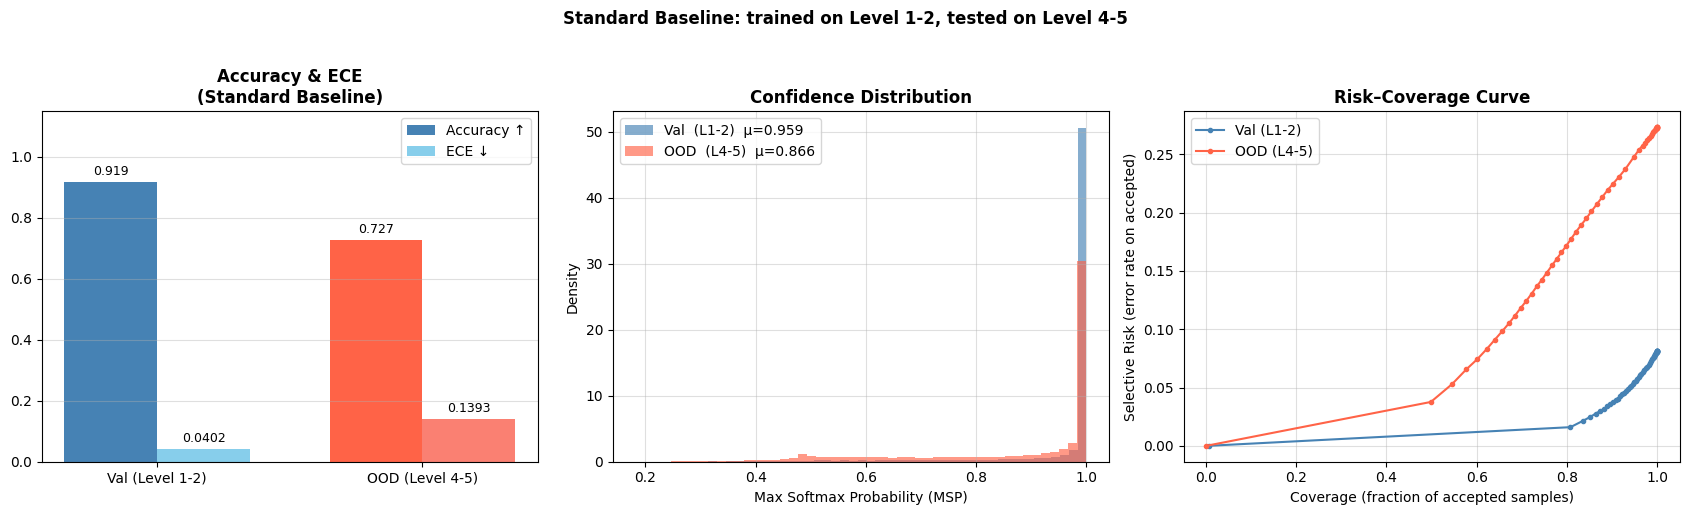

Saved: baseline_b_analysis.png


In [33]:
import matplotlib.pyplot as plt
import numpy as np

val_msp  = val_probs.max(dim=1).values.numpy()
ood_msp  = ood_probs.max(dim=1).values.numpy()

val_curve = risk_coverage_curve_from_msp(val_probs, val_labels)
ood_curve = risk_coverage_curve_from_msp(ood_probs, ood_labels)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Plot 1: Accuracy & ECE grouped bar ───────────────────────────────────────
ax = axes[0]
groups = ["Val (Level 1-2)", "OOD (Level 4-5)"]
acc_vals = [val_metrics["clean_accuracy"], ood_metrics["clean_accuracy"]]
ece_vals = [val_metrics["ECE"],            ood_metrics["ECE"]]
x, w = np.arange(2), 0.35
b1 = ax.bar(x - w / 2, acc_vals, w, label="Accuracy ↑", color=["steelblue", "tomato"])
b2 = ax.bar(x + w / 2, ece_vals, w, label="ECE ↓",      color=["skyblue",   "salmon"])
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.4f", padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylim(0, 1.15)
ax.set_title("Accuracy & ECE\n(Standard Baseline)", fontweight="bold")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.4)

# ── Plot 2: MSP distribution ──────────────────────────────────────────────────
ax = axes[1]
ax.hist(val_msp, bins=50, alpha=0.65, density=True, color="steelblue",
        label=f"Val  (L1-2)  μ={val_msp.mean():.3f}")
ax.hist(ood_msp, bins=50, alpha=0.65, density=True, color="tomato",
        label=f"OOD  (L4-5)  μ={ood_msp.mean():.3f}")
ax.set_xlabel("Max Softmax Probability (MSP)")
ax.set_ylabel("Density")
ax.set_title("Confidence Distribution", fontweight="bold")
ax.legend(); ax.grid(alpha=0.4)

# ── Plot 3: Risk–Coverage curve ───────────────────────────────────────────────
ax = axes[2]
ax.plot([p["coverage"] for p in val_curve],
        [p["risk"]     for p in val_curve],
        "o-", ms=3, lw=1.5, color="steelblue", label="Val (L1-2)")
ax.plot([p["coverage"] for p in ood_curve],
        [p["risk"]     for p in ood_curve],
        "o-", ms=3, lw=1.5, color="tomato",    label="OOD (L4-5)")
ax.set_xlabel("Coverage (fraction of accepted samples)")
ax.set_ylabel("Selective Risk (error rate on accepted)")
ax.set_title("Risk–Coverage Curve", fontweight="bold")
ax.legend(); ax.grid(alpha=0.4)

fig.suptitle(
    "Standard Baseline: trained on Level 1-2, tested on Level 4-5",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("baseline_b_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: baseline_b_analysis.png")

### 5.2 Gaussian-Noise Augmented Training

In [27]:
# ── 5.2  Gaussian-Noise Augmented Training Functions ─────────────────────────
import time

def add_gaussian_noise(imgs: torch.Tensor, sigma: float) -> torch.Tensor:
    """Add i.i.d. Gaussian noise N(0, sigma^2) and clamp to [0, 1]."""
    return torch.clamp(imgs + torch.randn_like(imgs) * sigma, 0.0, 1.0)


def _train_one_epoch_gauss(model, loader, optimizer, criterion, device,
                           epoch, total_epochs, sigma):
    model.train()
    total_loss, n = 0.0, 0
    n_batches = len(loader)

    for batch in loader:
        imgs   = batch["image"].to(device)
        labels = batch["signType"].to(device)

        imgs_noisy = add_gaussian_noise(imgs, sigma)
        loss = criterion(model(imgs_noisy), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n += 1
        if n % 50 == 0 or n == n_batches:
            print(f"  Epoch {epoch}/{total_epochs}  batch {n}/{n_batches}"
                  f"  avg_loss={total_loss/n:.4f}", flush=True)

    return total_loss / n


def train_gauss_resnet(model, train_loader, val_loader,
                       epochs=20, lr=1e-3, weight_decay=1e-4,
                       sigma=0.2,
                       device="cuda", save_path="gauss_resnet.pth"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    history   = {"loss": [], "val_acc": []}

    print(f"Gaussian-Noise Augmented Training  sigma={sigma:.2f}"
          f"  (~{sigma*255:.0f}/255 pixel noise)\n")

    for ep in range(1, epochs + 1):
        t0      = time.time()
        loss    = _train_one_epoch_gauss(
            model, train_loader, optimizer, criterion, device,
            ep, epochs, sigma)
        val_acc = _eval_acc(model, val_loader, device)
        scheduler.step()
        elapsed = time.time() - t0

        history["loss"].append(loss)
        history["val_acc"].append(val_acc)
        print(f"[Epoch {ep:3d}/{epochs}]  loss={loss:.4f}  "
              f"val_acc={val_acc:.4f}  ({elapsed:.0f}s)", flush=True)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"\nBest val_acc = {best_acc:.4f}  →  saved: {save_path}")
    return history

In [29]:
# ── Run training ──────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}\n")

gauss_model   = ResNetBaseline(num_classes=14)
gauss_history = train_gauss_resnet(
    gauss_model,
    baseline_train_loader,   # identical DataLoader as baseline (level 1-2)
    baseline_val_loader,
    epochs=5,
    lr=1e-3,
    sigma=0.2,               # moderate Gaussian noise (~51/255 per pixel)
    device=device,
    save_path="gauss_resnet.pth",
)

gauss_model.load_state_dict(torch.load("gauss_resnet.pth", map_location=device))
gauss_model.to(device).eval()
print("Best checkpoint loaded.")

Device: cuda

Gaussian-Noise Augmented Training  sigma=0.20  (~51/255 pixel noise)

  Epoch 1/5  batch 50/1368  avg_loss=1.0707
  Epoch 1/5  batch 100/1368  avg_loss=0.7989
  Epoch 1/5  batch 150/1368  avg_loss=0.6698
  Epoch 1/5  batch 200/1368  avg_loss=0.5800
  Epoch 1/5  batch 250/1368  avg_loss=0.5144
  Epoch 1/5  batch 300/1368  avg_loss=0.4639
  Epoch 1/5  batch 350/1368  avg_loss=0.4265
  Epoch 1/5  batch 400/1368  avg_loss=0.3944
  Epoch 1/5  batch 450/1368  avg_loss=0.3675
  Epoch 1/5  batch 500/1368  avg_loss=0.3464
  Epoch 1/5  batch 550/1368  avg_loss=0.3272
  Epoch 1/5  batch 600/1368  avg_loss=0.3116
  Epoch 1/5  batch 650/1368  avg_loss=0.2979
  Epoch 1/5  batch 700/1368  avg_loss=0.2860
  Epoch 1/5  batch 750/1368  avg_loss=0.2739
  Epoch 1/5  batch 800/1368  avg_loss=0.2634
  Epoch 1/5  batch 850/1368  avg_loss=0.2543
  Epoch 1/5  batch 900/1368  avg_loss=0.2458
  Epoch 1/5  batch 950/1368  avg_loss=0.2381
  Epoch 1/5  batch 1000/1368  avg_loss=0.2310
  Epoch 1/5  bat

In [26]:
# ─── Collect outputs & compare: Baseline vs Gaussian-Noise ───────────────────

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load checkpoints
_baseline_g = ResNetBaseline(num_classes=14)
_baseline_g.load_state_dict(torch.load("baseline_resnet.pth", map_location=device))
_baseline_g.to(device).eval()

_gauss = ResNetBaseline(num_classes=14)
_gauss.load_state_dict(torch.load("gauss_resnet.pth", map_location=device))
_gauss.to(device).eval()

print("Both checkpoints loaded.")

# Collect outputs
g_val_probs_b, g_val_labels = collect_outputs(_baseline_g, baseline_val_loader, device)
g_ood_probs_b, g_ood_labels = collect_outputs(_baseline_g, baseline_ood_loader, device)
g_val_probs_g, _            = collect_outputs(_gauss,      baseline_val_loader, device)
g_ood_probs_g, _            = collect_outputs(_gauss,      baseline_ood_loader, device)

g_val_b = evaluate_id_metrics(g_val_probs_b, g_val_labels)
g_ood_b = evaluate_id_metrics(g_ood_probs_b, g_ood_labels)
g_val_g = evaluate_id_metrics(g_val_probs_g, g_val_labels)
g_ood_g = evaluate_id_metrics(g_ood_probs_g, g_ood_labels)

# Comparison table
header = (f"{'Metric':<20} {'Base-Val':>10} {'Base-OOD':>10} "
          f"{'Gauss-Val':>10} {'Gauss-OOD':>10}")
sep = "─" * len(header)
print(sep); print(header); print(sep)
for k in g_val_b:
    print(f"{k:<20} {g_val_b[k]:>10.4f} {g_ood_b[k]:>10.4f} "
          f"{g_val_g[k]:>10.4f} {g_ood_g[k]:>10.4f}")
print(sep)

Both checkpoints loaded.


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


────────────────────────────────────────────────────────────────
Metric                 Base-Val   Base-OOD  Gauss-Val  Gauss-OOD
────────────────────────────────────────────────────────────────
clean_accuracy           0.9186     0.7266     0.9049     0.6976
NLL                      0.3483     1.1416     0.4459     1.4300
Brier                    0.1279     0.4095     0.1521     0.4704
ECE                      0.0402     0.1393     0.0547     0.1580
────────────────────────────────────────────────────────────────


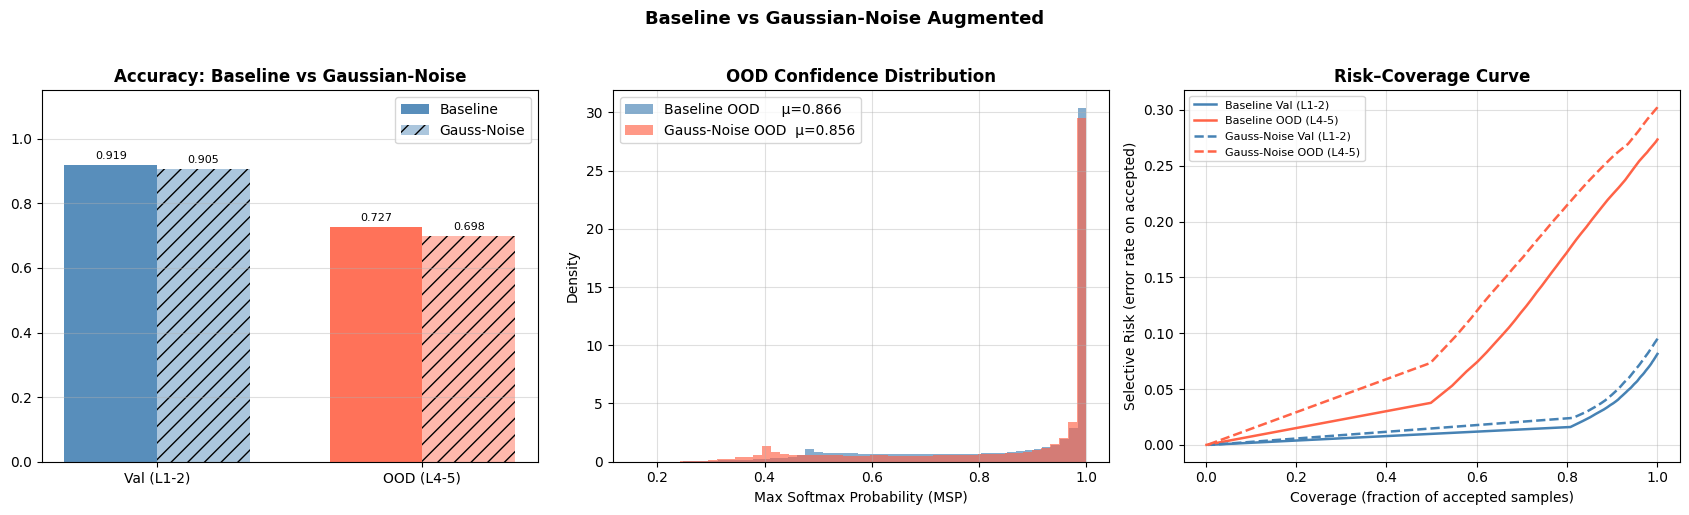

Saved: gauss_comparison.png


In [27]:
# ── Plots: Baseline vs Gaussian-Noise ─────────────────────────────────────────
b_val_msp_g = g_val_probs_b.max(dim=1).values.numpy()
b_ood_msp_g = g_ood_probs_b.max(dim=1).values.numpy()
g_val_msp   = g_val_probs_g.max(dim=1).values.numpy()
g_ood_msp   = g_ood_probs_g.max(dim=1).values.numpy()

b_val_curve_g = risk_coverage_curve_from_msp(g_val_probs_b, g_val_labels)
b_ood_curve_g = risk_coverage_curve_from_msp(g_ood_probs_b, g_ood_labels)
g_val_curve   = risk_coverage_curve_from_msp(g_val_probs_g, g_val_labels)
g_ood_curve   = risk_coverage_curve_from_msp(g_ood_probs_g, g_ood_labels)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Accuracy comparison bar
ax = axes[0]
x, w = np.arange(2), 0.35
b1 = ax.bar(x - w/2,
            [g_val_b["clean_accuracy"], g_ood_b["clean_accuracy"]],
            w, label="Baseline",    color=["steelblue", "tomato"], alpha=0.9)
b2 = ax.bar(x + w/2,
            [g_val_g["clean_accuracy"], g_ood_g["clean_accuracy"]],
            w, label="Gauss-Noise", color=["steelblue", "tomato"], alpha=0.45, hatch="//")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Val (L1-2)", "OOD (L4-5)"])
ax.set_ylim(0, 1.15)
ax.set_title("Accuracy: Baseline vs Gaussian-Noise",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)

# Plot 2: OOD MSP distribution
ax = axes[1]
ax.hist(b_ood_msp_g, bins=50, alpha=0.65, density=True, color="steelblue",
        label=f"Baseline OOD     \u03bc={b_ood_msp_g.mean():.3f}")
ax.hist(g_ood_msp,   bins=50, alpha=0.65, density=True, color="tomato",
        label=f"Gauss-Noise OOD  \u03bc={g_ood_msp.mean():.3f}")
ax.set_xlabel("Max Softmax Probability (MSP)")
ax.set_ylabel("Density")
ax.set_title("OOD Confidence Distribution",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.4)

# Plot 3: Risk-Coverage (4 curves)
ax = axes[2]
ax.plot([p["coverage"] for p in b_val_curve_g],
        [p["risk"]     for p in b_val_curve_g],
        "-",  lw=1.8, color="steelblue", label="Baseline Val (L1-2)")
ax.plot([p["coverage"] for p in b_ood_curve_g],
        [p["risk"]     for p in b_ood_curve_g],
        "-",  lw=1.8, color="tomato",    label="Baseline OOD (L4-5)")
ax.plot([p["coverage"] for p in g_val_curve],
        [p["risk"]     for p in g_val_curve],
        "--", lw=1.8, color="steelblue", label="Gauss-Noise Val (L1-2)")
ax.plot([p["coverage"] for p in g_ood_curve],
        [p["risk"]     for p in g_ood_curve],
        "--", lw=1.8, color="tomato",    label="Gauss-Noise OOD (L4-5)")
ax.set_xlabel("Coverage (fraction of accepted samples)")
ax.set_ylabel("Selective Risk (error rate on accepted)")
ax.set_title("Risk\u2013Coverage Curve",
             fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.4)

fig.suptitle(
    "Baseline vs Gaussian-Noise Augmented",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("gauss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gauss_comparison.png")


### 5.3 Multi-Corruption Augmented Training

In [26]:
# ── Training Functions ────────────────────────────────────────────────────────
import time
import random
import torchvision.transforms.functional as TF

# ── Multi-corruption Augmentation (per-image, mixed with clean) ──────────────

def corrupt_single_image(img: torch.Tensor) -> torch.Tensor:
    """Apply one random corruption to a single image tensor [C, H, W] in [0,1]."""
    c = random.randint(0, 4)

    if c == 0:    # Gaussian noise (moderate)
        img = torch.clamp(img + torch.randn_like(img) * 0.15, 0., 1.)

    elif c == 1:  # Gaussian blur
        k     = random.choice([3, 5, 7])
        sigma = random.uniform(1.0, 2.0)
        img   = TF.gaussian_blur(img, kernel_size=k, sigma=sigma)

    elif c == 2:  # darkening (moderate)
        factor = random.uniform(0.3, 0.6)
        img = torch.clamp(img * factor, 0., 1.)

    elif c == 3:  # over-exposure (moderate)
        factor = random.uniform(1.5, 2.0)
        img = torch.clamp(img * factor, 0., 1.)

    else:         # haze: reduce contrast + brightness shift
        alpha = random.uniform(0.4, 0.6)
        beta  = random.uniform(0.2, 0.4)
        img = torch.clamp(img * alpha + beta, 0., 1.)

    return img


def augment_batch_mixed(imgs: torch.Tensor, corrupt_ratio: float = 0.5) -> torch.Tensor:
    """
    For each image in the batch, with probability `corrupt_ratio` apply a
    random corruption; otherwise keep the clean image.
    """
    out = []
    for img in imgs:
        if random.random() < corrupt_ratio:
            out.append(corrupt_single_image(img))
        else:
            out.append(img)
    return torch.stack(out)


# ── Augmented training epoch ──────────────────────────────────────────────────
def _train_one_epoch_aug(model, loader, optimizer, criterion, device,
                         epoch, total_epochs, corrupt_ratio):
    model.train()
    total_loss, n = 0.0, 0
    n_batches = len(loader)

    for batch in loader:
        imgs   = batch["image"]             # keep on CPU for augmentation
        labels = batch["signType"].to(device)

        imgs_aug = augment_batch_mixed(imgs, corrupt_ratio).to(device)
        loss = criterion(model(imgs_aug), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n += 1
        if n % 50 == 0 or n == n_batches:
            print(f"  Epoch {epoch}/{total_epochs}  batch {n}/{n_batches}"
                  f"  avg_loss={total_loss/n:.4f}", flush=True)

    return total_loss / n


# ── Training loop ─────────────────────────────────────────────────────────────
def train_robust_resnet(model, train_loader, val_loader,
                        epochs=20, lr=1e-3, weight_decay=1e-4,
                        corrupt_ratio=0.5,
                        device="cuda", save_path="robust_resnet.pth"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    history   = {"loss": [], "val_acc": []}

    print(f"Multi-corruption Augmentation Training  (corrupt_ratio={corrupt_ratio})")
    print("  Pool: Noise / Blur / Darkening / Exposure / Haze")
    print(f"  {corrupt_ratio*100:.0f}% corrupted + {(1-corrupt_ratio)*100:.0f}% clean per batch\n")

    for ep in range(1, epochs + 1):
        t0      = time.time()
        loss    = _train_one_epoch_aug(
            model, train_loader, optimizer, criterion, device,
            ep, epochs, corrupt_ratio)
        val_acc = _eval_acc(model, val_loader, device)
        scheduler.step()
        elapsed = time.time() - t0

        history["loss"].append(loss)
        history["val_acc"].append(val_acc)
        print(f"[Epoch {ep:3d}/{epochs}]  loss={loss:.4f}  "
              f"val_acc={val_acc:.4f}  ({elapsed:.0f}s)", flush=True)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"\nBest val_acc = {best_acc:.4f}  \u2192  saved: {save_path}")
    return history


In [27]:
# ── Run ──────────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
robust_model   = ResNetBaseline(num_classes=14)
robust_history = train_robust_resnet(
    robust_model,
    baseline_train_loader,   # identical DataLoader as baseline (level 1-2)
    baseline_val_loader,
    epochs=5,
    lr=1e-3,
    corrupt_ratio=0.5,       # 50% corrupted + 50% clean per batch
    device=device,
    save_path="robust_resnet.pth",
)

robust_model.load_state_dict(torch.load("robust_resnet.pth", map_location=device))
robust_model.to(device).eval()
print("Best checkpoint loaded.")

Multi-corruption Augmentation Training  (corrupt_ratio=0.5)
  Pool: Noise / Blur / Darkening / Exposure / Haze
  50% corrupted + 50% clean per batch

  Epoch 1/5  batch 50/1368  avg_loss=1.2068
  Epoch 1/5  batch 100/1368  avg_loss=0.9268
  Epoch 1/5  batch 150/1368  avg_loss=0.7730
  Epoch 1/5  batch 200/1368  avg_loss=0.6672
  Epoch 1/5  batch 250/1368  avg_loss=0.5928
  Epoch 1/5  batch 300/1368  avg_loss=0.5381
  Epoch 1/5  batch 350/1368  avg_loss=0.4926
  Epoch 1/5  batch 400/1368  avg_loss=0.4509
  Epoch 1/5  batch 450/1368  avg_loss=0.4201
  Epoch 1/5  batch 500/1368  avg_loss=0.3950
  Epoch 1/5  batch 550/1368  avg_loss=0.3719
  Epoch 1/5  batch 600/1368  avg_loss=0.3521
  Epoch 1/5  batch 650/1368  avg_loss=0.3333
  Epoch 1/5  batch 700/1368  avg_loss=0.3174
  Epoch 1/5  batch 750/1368  avg_loss=0.3041
  Epoch 1/5  batch 800/1368  avg_loss=0.2918
  Epoch 1/5  batch 850/1368  avg_loss=0.2810
  Epoch 1/5  batch 900/1368  avg_loss=0.2703
  Epoch 1/5  batch 950/1368  avg_loss=0.2

In [28]:
# ─── Collect outputs & compute metrics ───────────────────

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load checkpoints 
_baseline  = ResNetBaseline(num_classes=14)
_baseline.load_state_dict(torch.load("baseline_resnet.pth", map_location=device))
_baseline.to(device).eval()

_robust = ResNetBaseline(num_classes=14)
_robust.load_state_dict(torch.load("robust_resnet.pth", map_location=device))
_robust.to(device).eval()

print("Both checkpoints loaded.")

# Collect outputs
cmp_val_probs_b,  cmp_val_labels  = collect_outputs(_baseline, baseline_val_loader, device)
cmp_ood_probs_b,  cmp_ood_labels  = collect_outputs(_baseline, baseline_ood_loader, device)
cmp_val_probs_r,  _               = collect_outputs(_robust,   baseline_val_loader, device)
cmp_ood_probs_r,  _               = collect_outputs(_robust,   baseline_ood_loader, device)

cmp_val_b = evaluate_id_metrics(cmp_val_probs_b, cmp_val_labels)
cmp_ood_b = evaluate_id_metrics(cmp_ood_probs_b, cmp_ood_labels)
cmp_val_r = evaluate_id_metrics(cmp_val_probs_r, cmp_val_labels)
cmp_ood_r = evaluate_id_metrics(cmp_ood_probs_r, cmp_ood_labels)

# Comparison table
header = (f"{'Metric':<20} {'Base-Val':>10} {'Base-OOD':>10} "
          f"{'Rob-Val':>10} {'Rob-OOD':>10}")
sep = "─" * len(header)
print(sep); print(header); print(sep)
for k in cmp_val_b:
    print(f"{k:<20} {cmp_val_b[k]:>10.4f} {cmp_ood_b[k]:>10.4f} "
          f"{cmp_val_r[k]:>10.4f} {cmp_ood_r[k]:>10.4f}")
print(sep)

Both checkpoints loaded.
────────────────────────────────────────────────────────────────
Metric                 Base-Val   Base-OOD    Rob-Val    Rob-OOD
────────────────────────────────────────────────────────────────
clean_accuracy           0.9186     0.7266     0.9314     0.8003
NLL                      0.3483     1.1416     0.2704     0.7427
Brier                    0.1279     0.4095     0.1047     0.2894
ECE                      0.0402     0.1393     0.0303     0.0838
────────────────────────────────────────────────────────────────


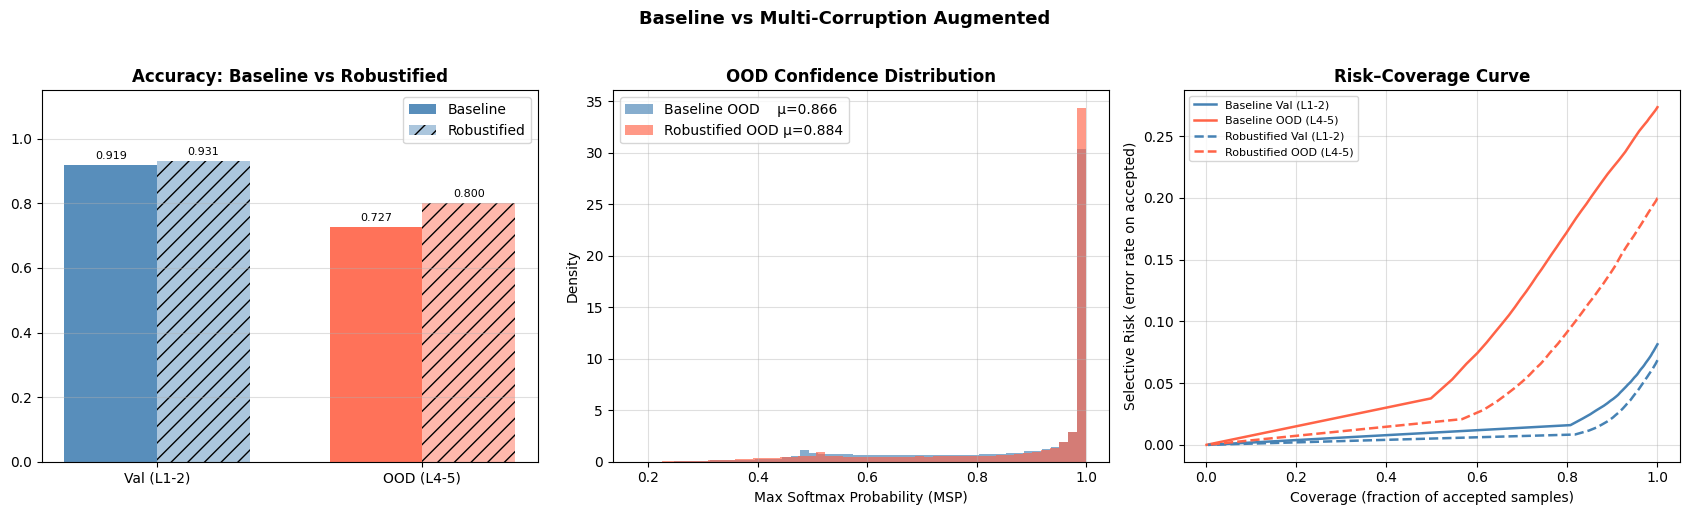

Saved: Multi-Corruption_comparison.png


In [29]:
# ── Plots ─────────────────────────────────────────────────────────────────────
b_val_msp = cmp_val_probs_b.max(dim=1).values.numpy()
b_ood_msp = cmp_ood_probs_b.max(dim=1).values.numpy()
r_val_msp = cmp_val_probs_r.max(dim=1).values.numpy()
r_ood_msp = cmp_ood_probs_r.max(dim=1).values.numpy()

b_val_curve = risk_coverage_curve_from_msp(cmp_val_probs_b, cmp_val_labels)
b_ood_curve = risk_coverage_curve_from_msp(cmp_ood_probs_b, cmp_ood_labels)
r_val_curve = risk_coverage_curve_from_msp(cmp_val_probs_r, cmp_val_labels)
r_ood_curve = risk_coverage_curve_from_msp(cmp_ood_probs_r, cmp_ood_labels)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Accuracy & ECE comparison bar
ax = axes[0]
x, w = np.arange(2), 0.35
b1 = ax.bar(x - w/2,
            [cmp_val_b["clean_accuracy"], cmp_ood_b["clean_accuracy"]],
            w, label="Baseline",    color=["steelblue", "tomato"], alpha=0.9)
b2 = ax.bar(x + w/2,
            [cmp_val_r["clean_accuracy"], cmp_ood_r["clean_accuracy"]],
            w, label="Robustified", color=["steelblue", "tomato"], alpha=0.45, hatch="//")
ax.bar_label(b1, fmt="%.3f", padding=3, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Val (L1-2)", "OOD (L4-5)"])
ax.set_ylim(0, 1.15)
ax.set_title("Accuracy: Baseline vs Robustified",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.4)

# Plot 2: OOD MSP distribution
ax = axes[1]
ax.hist(b_ood_msp, bins=50, alpha=0.65, density=True, color="steelblue",
        label=f"Baseline OOD    μ={b_ood_msp.mean():.3f}")
ax.hist(r_ood_msp, bins=50, alpha=0.65, density=True, color="tomato",
        label=f"Robustified OOD μ={r_ood_msp.mean():.3f}")
ax.set_xlabel("Max Softmax Probability (MSP)")
ax.set_ylabel("Density")
ax.set_title("OOD Confidence Distribution",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.4)

# Plot 3: Risk-Coverage (4 curves)
ax = axes[2]
ax.plot([p["coverage"] for p in b_val_curve],
        [p["risk"]     for p in b_val_curve],
        "-",  lw=1.8, color="steelblue", label="Baseline Val (L1-2)")
ax.plot([p["coverage"] for p in b_ood_curve],
        [p["risk"]     for p in b_ood_curve],
        "-",  lw=1.8, color="tomato",    label="Baseline OOD (L4-5)")
ax.plot([p["coverage"] for p in r_val_curve],
        [p["risk"]     for p in r_val_curve],
        "--", lw=1.8, color="steelblue", label="Robustified Val (L1-2)")
ax.plot([p["coverage"] for p in r_ood_curve],
        [p["risk"]     for p in r_ood_curve],
        "--", lw=1.8, color="tomato",    label="Robustified OOD (L4-5)")
ax.set_xlabel("Coverage (fraction of accepted samples)")
ax.set_ylabel("Selective Risk (error rate on accepted)")
ax.set_title("Risk–Coverage Curve",
             fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.4)

fig.suptitle(
    "Baseline vs Multi-Corruption Augmented",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("Multi-Corruption_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Multi-Corruption_comparison.png")